<a href="https://colab.research.google.com/github/anushkaaa-kolhe/AIML-lab/blob/main/A__Search_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

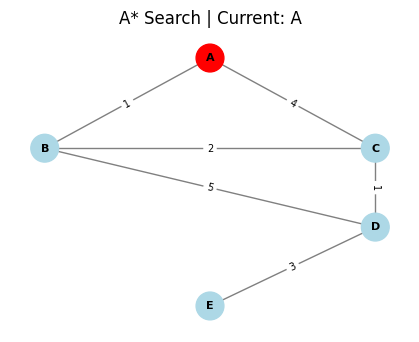

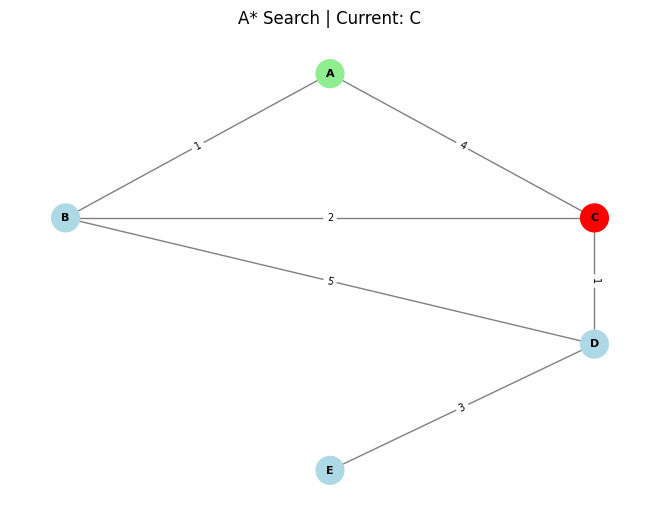

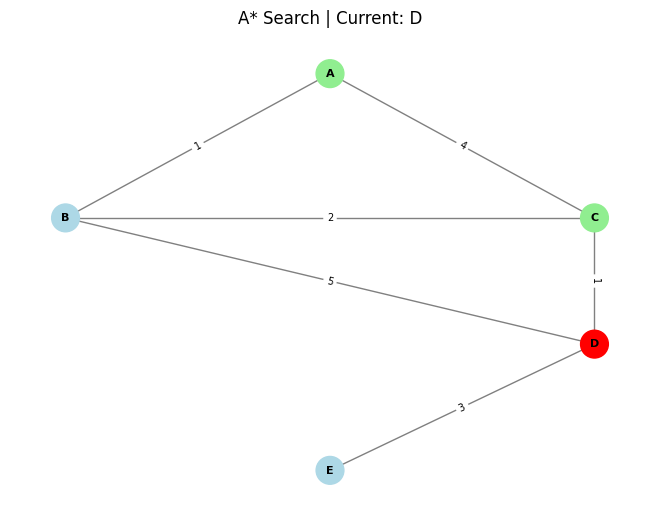

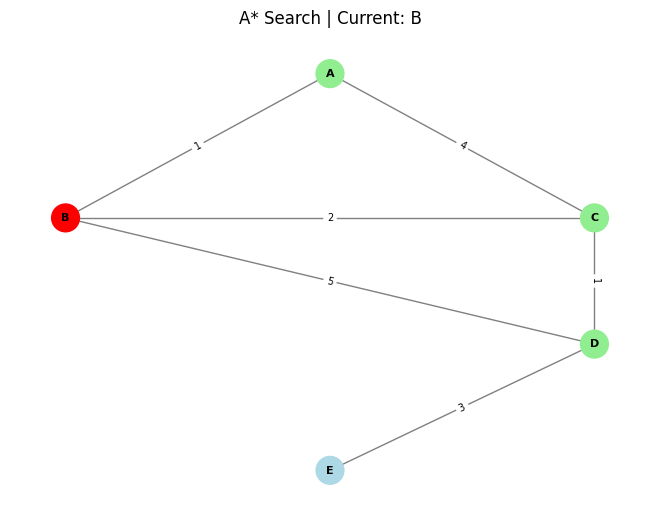

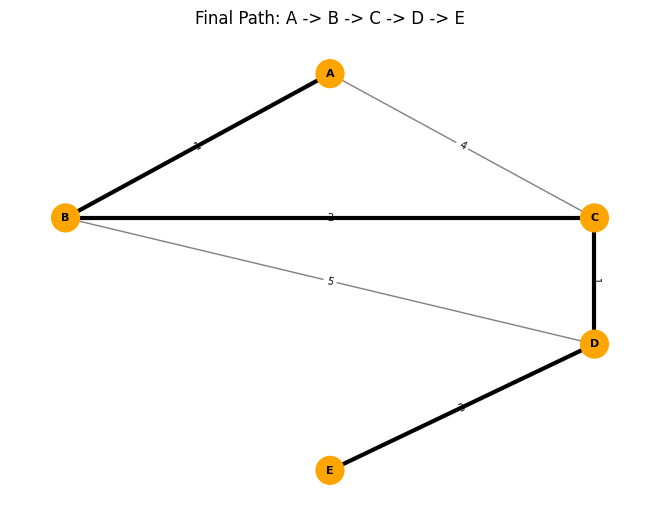

A* Path: A -> B -> C -> D -> E
Total Cost: 8


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('A', 1), ('C', 2), ('D', 5)],
    'C': [('A', 4), ('B', 2), ('D', 1)],
    'D': [('B', 5), ('C', 1), ('E', 3)],
    'E': [('D', 3)]
}

heuristic = {'A': 7, 'B': 6, 'C': 2, 'D': 1, 'E': 0}

start = 'A'
goal = 'E'

G = nx.Graph()

for node in graph:
    for neighbour, cost in graph[node]:
        G.add_edge(node, neighbour, weight=cost)

pos = {
    'A': (0, 1.5),
    'B': (-0.7, 0.7),
    'C': (0.7, 0.7),
    'D': (0.7, 0),
    'E': (0, -0.7)
}

g = {node: float('inf') for node in graph}
g[start] = 0
parent = {start: None}

queue = [(heuristic[start], start)]
visited = set()
path = []

plt.figure(figsize=(4, 3))

while queue:
    f, current = heapq.heappop(queue)

    if current in visited:
        continue

    visited.add(current)

    if current == goal:
        break

    for neighbour, cost in graph[current]:
        new_g = g[current] + cost

        if new_g < g[neighbour]:
            g[neighbour] = new_g
            parent[neighbour] = current
            heapq.heappush(
                queue,
                (new_g + heuristic[neighbour], neighbour)
            )

    plt.clf()

    colors = []

    for node in G.nodes():
        if node == current:
            colors.append("red")
        elif node in visited:
            colors.append("lightgreen")
        else:
            colors.append("lightblue")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=colors,
        node_size=400,
        font_size=8,
        font_weight='bold',
        edge_color='gray'
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=nx.get_edge_attributes(G, 'weight'),
        font_size=7
    )

    plt.title(f"A* Search | Current: {current}")
    plt.axis('off')
    plt.pause(1)

current = goal

while current is not None:
    path.append(current)
    current = parent[current]

path.reverse()

plt.clf()

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=[
        "orange" if node in path else "lightblue"
        for node in G.nodes()
    ],
    node_size=400,
    font_size=8,
    font_weight='bold',
    edge_color='gray'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(G, 'weight'),
    font_size=7
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=list(zip(path, path[1:])),
    width=3
)

plt.title(f"Final Path: {' -> '.join(path)}")
plt.axis('off')
plt.show()

print("A* Path:", " -> ".join(path))
print("Total Cost:", g[goal])